# 03. Model Evaluation & Explainable AI (Grad-CAM)
This notebook loads the trained global weights for **Standard FedAvg** and **FedProx**, evaluates their metrics, and computes Grad-CAM attention heatmaps to explain model decisions.

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Add project root to path
sys.path.append(os.path.abspath('..'))

from models.mobilenet import get_mobilenet
from utils.dataset import load_centralized_data, get_transforms
from app import GradCAM, CLASS_NAMES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluation running on: {device}")

2026-08-25 13:52:38.567 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-25 13:52:40.095 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-25 13:52:40.301 
  command:

    streamlit run C:\Users\Asus\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-25 13:52:40.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-25 13:52:40.301 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-25 13:52:41.023 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-25 13:52:41.024 Thread 'MainThread': missing ScriptRunContext! This warning can be

Evaluation running on: cuda


In [2]:
# 1. Load trained models
num_classes = len(CLASS_NAMES)

def load_model(weight_filename):
    model = get_mobilenet(num_classes=num_classes, pretrained=False).to(device)
    path = os.path.join('..', 'results', weight_filename)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    model.eval()
    return model

fedavg_model = load_model('fedavg_model.pth')
fedprox_model = load_model('fedprox_model.pth')
print("✅ FedAvg and FedProx models loaded successfully.")

✅ FedAvg and FedProx models loaded successfully.



❄️ Freezing 4128 test images to data/test_holdout for the Streamlit dashboard...
✅ Test data successfully frozen!



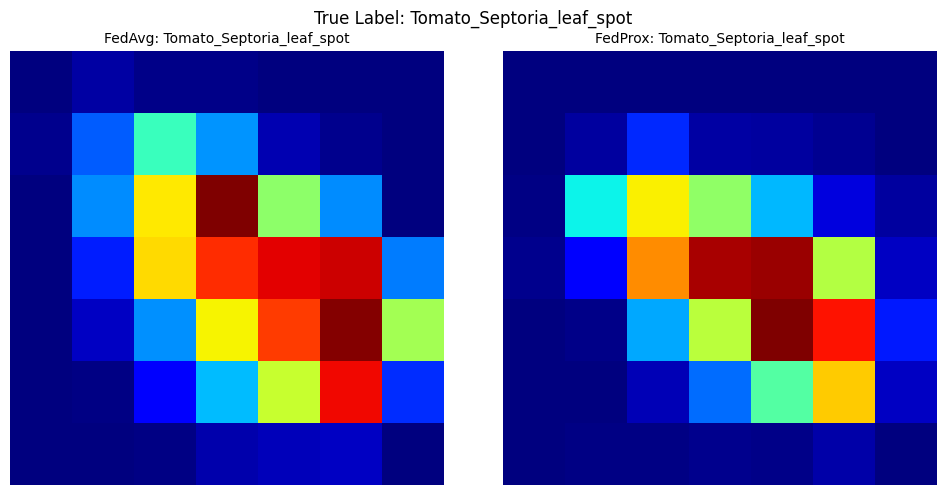

In [3]:
# 2. Interactive Grad-CAM on a sample validation image
_, val_loader, _ = load_centralized_data(data_dir='../data/PlantVillage', batch_size=1)
sample_img, sample_label = next(iter(val_loader))
sample_img = sample_img.to(device)

def explain_prediction(model, tensor, title):
    output = model(tensor)
    pred_idx = torch.argmax(output, 1).item()
    cam = GradCAM(model)
    heatmap = cam.generate_heatmap(tensor, pred_idx)
    cam.remove_hooks()
    return CLASS_NAMES[pred_idx], heatmap

pred_avg, heat_avg = explain_prediction(fedavg_model, sample_img, "FedAvg")
pred_prox, heat_prox = explain_prediction(fedprox_model, sample_img, "FedProx")

# Display comparisons
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(heat_avg, cmap='jet')
axes[0].set_title(f"FedAvg: {pred_avg}", fontsize=10)
axes[0].axis('off')

axes[1].imshow(heat_prox, cmap='jet')
axes[1].set_title(f"FedProx: {pred_prox}", fontsize=10)
axes[1].axis('off')

plt.suptitle(f"True Label: {CLASS_NAMES[sample_label.item()]}", fontsize=12)
plt.tight_layout()
plt.show()